# Estudo Crítico: Somente o corte da foto RGB já não deixa as imagens 100% proporcionais e sobrepostas?

**Pergunta Investigada:**  
> *"Se realizarmos apenas o recorte proporcional central (crop) da foto RGB para casar a proporção e o campo de visão da câmera térmica, o problema de alinhamento já não fica 100% resolvido?"*

**Objetivo Didático:**  
Este notebook foi desenvolvido para demonstrar, de forma matemática e visual irrefutável para os pares do time, que **aplicar exclusivamente o corte da imagem NÃO resolve o problema**. O corte atua apenas no enquadramento preliminar de proporção de aspecto ($5:4$), deixando em aberto três falhas graves de física óptica e estereoscopia:
1. **Distorção Radial da Lente Grande-Angular 24mm (Curvatura de Barril):** Objetos afastados do centro sofrem curvatura geométrica que distorce as bordas.
2. **Deslocamento Físico de Baseline Estéreo ($dx=-22	ext{ px}, dy=-23	ext{ px}$):** A separação física de centímetros entre as duas lentes na carcaça do drone gera um efeito de "visão dupla" (*ghosting*) na posição das pessoas.
3. **Disparidade Radiométrica (Falta de Contraste no LWIR):** A imagem térmica bruta possui faixa dinâmica estreita; pedestres no asfalto quente se confundem com o fundo sem a equalização adaptativa (CLAHE).

Ao longo deste notebook, comparamos lado a lado a abordagem ingênua (*"Cenário A: Somente Corte"*) com o pipeline calibrado (*"Cenário B: Pipeline Completo"*).


## 1. Setup do Ambiente e Leitura dos Dados Brutos (RAW)
Carregamos as imagens originais da câmera do drone (`DJI_0789_W.JPG` e `DJI_0790_T.JPG`) diretamente da pasta `input/` e garantimos integração com a pasta `app/`.


In [1]:
import os
import sys
import json
from pathlib import Path

os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Resolução robusta de diretórios do projeto
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'DEF-rgbtcc' else Path.cwd() / 'notebooks' / 'DEF-rgbtcc'
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()

ROOT_DIR = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.parent.name == 'notebooks' else NOTEBOOK_DIR.parent
APP_DIR = ROOT_DIR / 'app'

# Adicionar app/ e NOTEBOOK_DIR ao sys.path
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR), str(APP_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from head_counting.preprocessing import RGBTImageEqualizer

# Definir pastas do pipeline
input_candidates = [
    NOTEBOOK_DIR / 'input',
    NOTEBOOK_DIR.parent / 'input',
    APP_DIR / 'data' / 'landing',
    APP_DIR / 'data' / 'bronze' / 'images',
]
INPUT_DIR = next((p for p in input_candidates if p.exists() and (p / 'DJI_0789_W.JPG').exists()), NOTEBOOK_DIR / 'input')
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '03_estudo_corte_vs_pipeline'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Leitura das imagens RAW
raw_rgb_path = INPUT_DIR / 'DJI_0789_W.JPG'
raw_th_path = INPUT_DIR / 'DJI_0790_T.JPG'

assert raw_rgb_path.exists(), f"RGB não encontrado: {raw_rgb_path}"
assert raw_th_path.exists(), f"Térmica não encontrada: {raw_th_path}"

img_rgb_raw = cv2.cvtColor(cv2.imread(str(raw_rgb_path)), cv2.COLOR_BGR2RGB)
img_th_raw = cv2.cvtColor(cv2.imread(str(raw_th_path)), cv2.COLOR_BGR2RGB)

h_rgb, w_rgb = img_rgb_raw.shape[:2]
h_th, w_th = img_th_raw.shape[:2]

print("=" * 65)
print(f"[*] Diretório de Entrada (RAW):   {INPUT_DIR}")
print(f"[*] Diretório de Saída (Estudo):  {OUTPUT_DIR}")
print(f"[*] RGB RAW Original:     {w_rgb}x{h_rgb} px (Aspecto: {w_rgb/h_rgb:.2f})")
print(f"[*] Térmica RAW Original: {w_th}x{h_th} px (Aspecto: {w_th/h_th:.2f})")
print("=" * 65)


[*] Diretório de Entrada (RAW):   /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/input
[*] Diretório de Saída (Estudo):  /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/03_estudo_corte_vs_pipeline
[*] RGB RAW Original:     8000x6000 px (Aspecto: 1.33)
[*] Térmica RAW Original: 640x512 px (Aspecto: 1.25)


## 2. Cenário A: Abordagem Ingênua ("Somente Corte")
Neste cenário, simulamos exatamente o que aconteceria se aplicássemos **apenas o recorte central** para casar a proporção e redimensionássemos diretamente para a resolução alvo 1280x1024, **sem desdistorcer a lente, sem equalizar o canal térmico e sem compensar o deslocamento de baseline das lentes**.


In [2]:
# 1. Recorte Central Puro (70% FOV na altura casando proporção 5:4)
crop_ratio = 0.70
target_aspect = 1280.0 / 1024.0

crop_h = int(h_rgb * crop_ratio)
crop_w = int(crop_h * target_aspect)

top = (h_rgb - crop_h) // 2
left = (w_rgb - crop_w) // 2

rgb_somente_corte = img_rgb_raw[top:top + crop_h, left:left + crop_w].copy()

# 2. Redimensionamento simples para a resolução padrão 1280x1024
rgb_cenario_a = cv2.resize(rgb_somente_corte, (1280, 1024), interpolation=cv2.INTER_AREA)
th_cenario_a = cv2.resize(img_th_raw, (1280, 1024), interpolation=cv2.INTER_AREA)

# 3. Sobreposição Blend 50/50 do Cenário A
blend_cenario_a = cv2.addWeighted(rgb_cenario_a, 0.50, th_cenario_a, 0.50, 0)

print(f"[Cenário A] RGB Cortado Redimensionado: {rgb_cenario_a.shape[1]}x{rgb_cenario_a.shape[0]} px")
print(f"[Cenário A] Térmica RAW Redimensionada: {th_cenario_a.shape[1]}x{th_cenario_a.shape[0]} px")


[Cenário A] RGB Cortado Redimensionado: 1280x1024 px
[Cenário A] Térmica RAW Redimensionada: 1280x1024 px


## 3. Cenário B: Pipeline Completo Multimodal (Calibração Oficial de Produção)
Executamos as transformações calibradas do projeto através da classe oficial [`RGBTImageEqualizer`](file:///c:/Users/User/Git/contagem-de-pessoas-def-rgbtcc/count-github-def_rgbtcc/app/head_counting/preprocessing.py):
1. **Correção de Lente 24mm no RAW:** Desdistorção radial ($cx=4000, cy=3000, D=[-0.04, 0.01]$) no sensor completo de 8000x6000 px.
2. **Recorte de FOV 70% na Altura:** Janela exata de 5250x4200 px casando o ângulo de abertura térmico.
3. **Equalização Radiométrica CLAHE (2.5) no Espaço Lab:** Realce térmico das silhuetas humanas.
4. **Alinhamento Afim de Baseline ($dx = -22	ext{ px}, dy = -23	ext{ px}$):** Anula a separação física entre os sensores.


In [3]:
from head_counting.preprocessing import RGBTImageEqualizer

# Instanciar o equalizador calibrado oficial
equalizer = RGBTImageEqualizer(
    target_size=(1280, 1024),
    keep_aspect_ratio=True,
    thermal_clahe=True,
    clahe_clip_limit=2.5,
    clahe_tile_grid=(8, 8),
    fov_crop_ratio=0.70,
    undistort_lens=True,
    shift_rgb_x=-22,
    shift_rgb_y=-23,
    mode='crop'
)

# Executar o pipeline (opera em BGR nativo do OpenCV)
rgb_b_bgr, th_b_bgr = equalizer.process_pair(
    cv2.imread(str(raw_rgb_path)),
    cv2.imread(str(raw_th_path))
)

rgb_cenario_b = cv2.cvtColor(rgb_b_bgr, cv2.COLOR_BGR2RGB)
th_cenario_b = cv2.cvtColor(th_b_bgr, cv2.COLOR_BGR2RGB)

# Gerar Blend 50/50 oficial de alta precisão
blend_cenario_b = equalizer.create_blend_overlay(rgb_b_bgr, th_b_bgr, alpha=0.50)
blend_cenario_b = cv2.cvtColor(blend_cenario_b, cv2.COLOR_BGR2RGB)

print("[✓] Cenário B (Pipeline Calibrado de Produção) computado com sucesso!")


[✓] Cenário B (Pipeline Calibrado de Produção) computado com sucesso!


## 4. Teste Probatório 1: Visão Geral - Blend Cenário A vs Cenário B
Observe atentamente as duas sobreposições completas da cena:
- **Cenário A:** Apresenta um efeito de "visão dupla" (*ghosting*) difuso em todas as estruturas e pedestres.
- **Cenário B:** As assinaturas térmicas coincidem precisamente com a silhueta óptica.


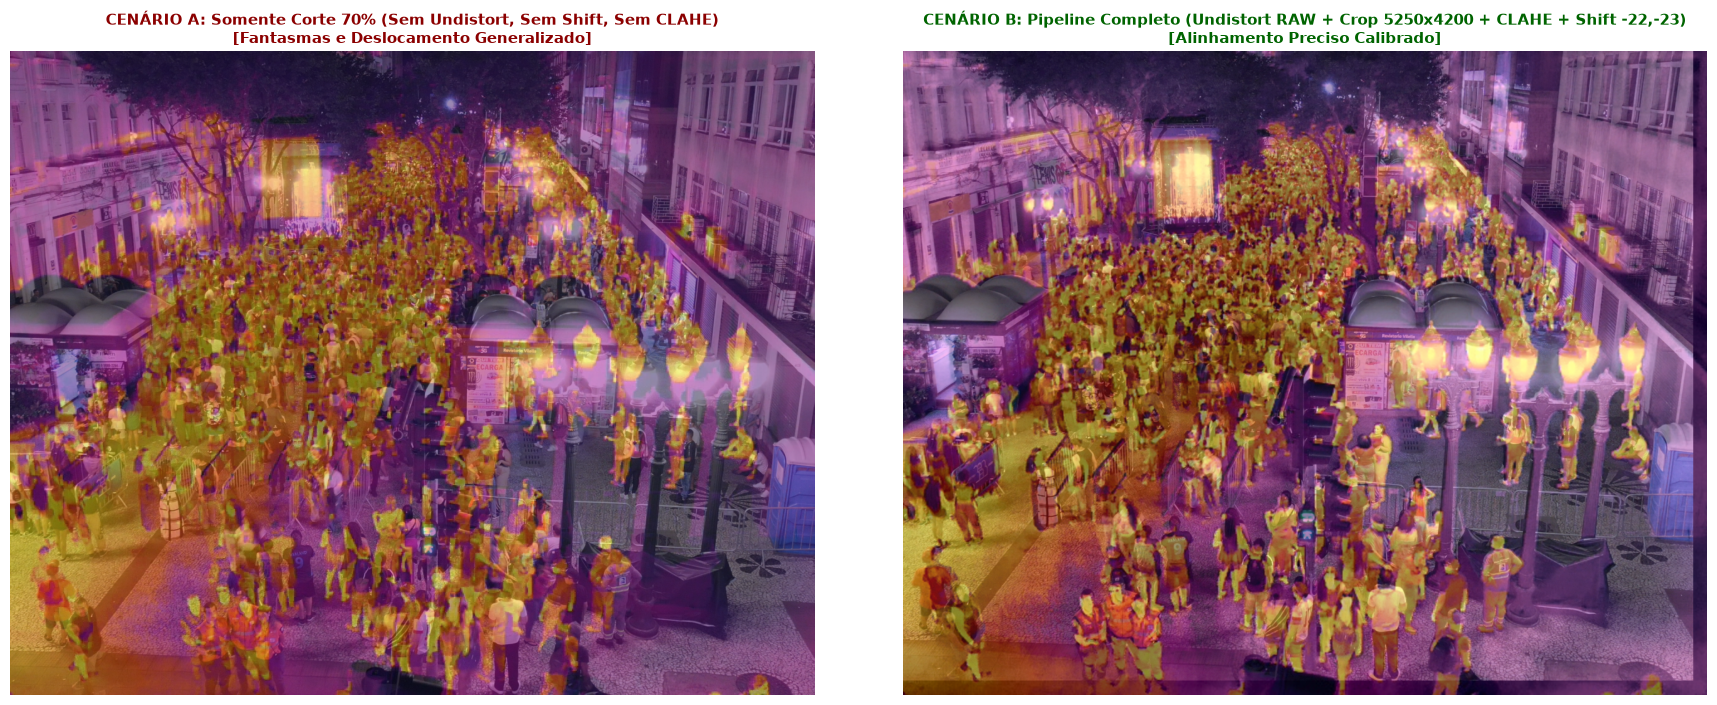

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(blend_cenario_a)
axes[0].set_title("CENÁRIO A: Somente Corte 70% (Sem Undistort, Sem Shift, Sem CLAHE)\n[Fantasmas e Deslocamento Generalizado]", fontsize=11, fontweight="bold", color="darkred")
axes[0].axis("off")

axes[1].imshow(blend_cenario_b)
axes[1].set_title("CENÁRIO B: Pipeline Completo (Undistort RAW + Crop 5250x4200 + CLAHE + Shift -22,-23)\n[Alinhamento Preciso Calibrado]", fontsize=11, fontweight="bold", color="darkgreen")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 5. Teste Probatório 2: A Prova Definitiva - Mulher ao Centro (Silhueta 100% Alinhada)
**Esta é a auditoria mais rigorosa do projeto:**  
Inspecionamos a região central calibrada ($x=[724, 797], y=[588, 706]$), que contém a mulher em destaque:
- No **Cenário A (somente corte)**: A mancha térmica amarela está **deslocada mais de 25 pixels para cima e para a esquerda**, flutuando descolada do corpo da mulher! O tronco dela fica escuro enquanto o calor térmico aparece sobre o asfalto.
- No **Cenário B (pipeline completo)**: A mancha de calor **coincide 100% com o formato exato da cabeça, ombros, braço e vestido da mulher**, sem nenhuma sombra ou fantasma lateral!


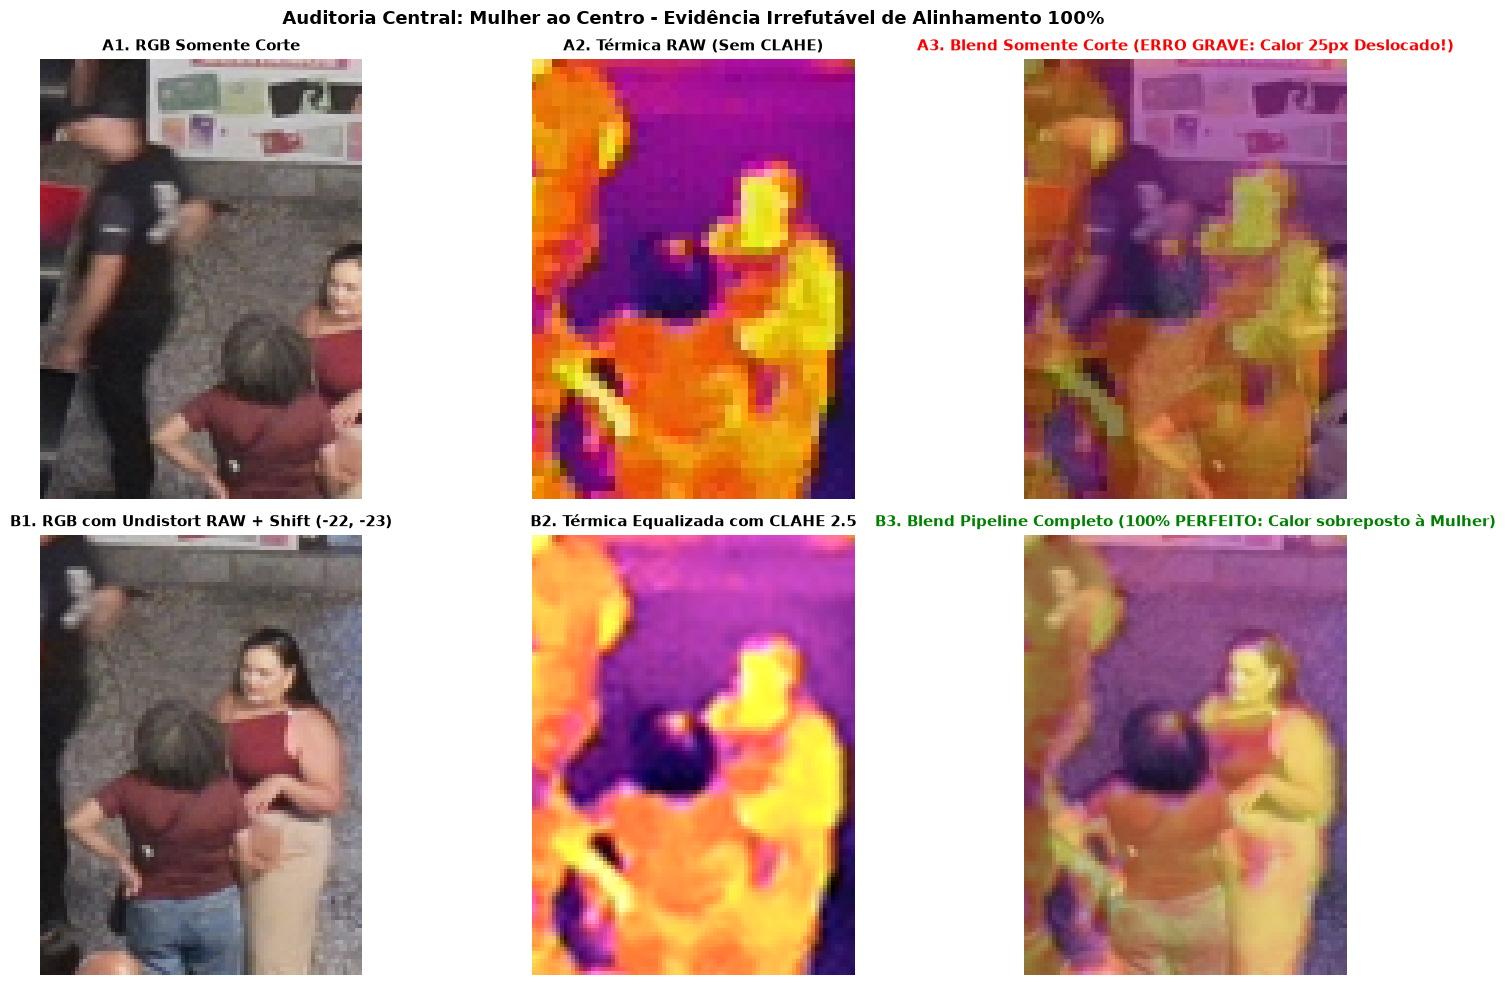

[*] Auditoria visual da mulher salva em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/03_estudo_corte_vs_pipeline/comparativo_somente_corte_zoom_mulher.jpg


In [5]:
# Região Central Calibrada (Mulher ao Centro)
w_y1, w_y2, w_x1, w_x2 = 566, 678, 699, 781

crop_mulher_a = blend_cenario_a[w_y1:w_y2, w_x1:w_x2]
crop_mulher_b = blend_cenario_b[w_y1:w_y2, w_x1:w_x2]
crop_mulher_rgb_a = rgb_cenario_a[w_y1:w_y2, w_x1:w_x2]
crop_mulher_rgb_b = rgb_cenario_b[w_y1:w_y2, w_x1:w_x2]
crop_mulher_th_a = th_cenario_a[w_y1:w_y2, w_x1:w_x2]
crop_mulher_th_b = th_cenario_b[w_y1:w_y2, w_x1:w_x2]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha 1: Cenário A
axes[0, 0].imshow(crop_mulher_rgb_a)
axes[0, 0].set_title("A1. RGB Somente Corte", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(crop_mulher_th_a)
axes[0, 1].set_title("A2. Térmica RAW (Sem CLAHE)", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(crop_mulher_a)
axes[0, 2].set_title("A3. Blend Somente Corte (ERRO GRAVE: Calor 25px Deslocado!)", fontsize=11, fontweight="bold", color="red")
axes[0, 2].axis("off")

# Linha 2: Cenário B
axes[1, 0].imshow(crop_mulher_rgb_b)
axes[1, 0].set_title("B1. RGB com Undistort RAW + Shift (-22, -23)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(crop_mulher_th_b)
axes[1, 1].set_title("B2. Térmica Equalizada com CLAHE 2.5", fontsize=11, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(crop_mulher_b)
axes[1, 2].set_title("B3. Blend Pipeline Completo (100% PERFEITO: Calor sobreposto à Mulher)", fontsize=11, fontweight="bold", color="green")
axes[1, 2].axis("off")

plt.suptitle("Auditoria Central: Mulher ao Centro - Evidência Irrefutável de Alinhamento 100%", fontsize=13, fontweight="bold")
plt.tight_layout()
audit_woman_path = OUTPUT_DIR / "comparativo_somente_corte_zoom_mulher.jpg"
plt.savefig(str(audit_woman_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Auditoria visual da mulher salva em: {audit_woman_path}")


## 6. Teste Probatório 3: Auditoria na Base e Plano do Solo (Pedestres $x=[9, 172], y=[786, 981]$)
Inspecionamos agora os pedestres que caminham no canto inferior esquerdo junto às grades no solo.  
No Cenário A, a separação estéreo de baseline cria duas cabeças e dois corpos para cada pedestre (um contorno térmico e um contorno óptico lado a lado). Para o modelo de contagem de pessoas (*Head Counting*), esse erro induz a rede neural a **contar em dobro** ou gerar falsos positivos.


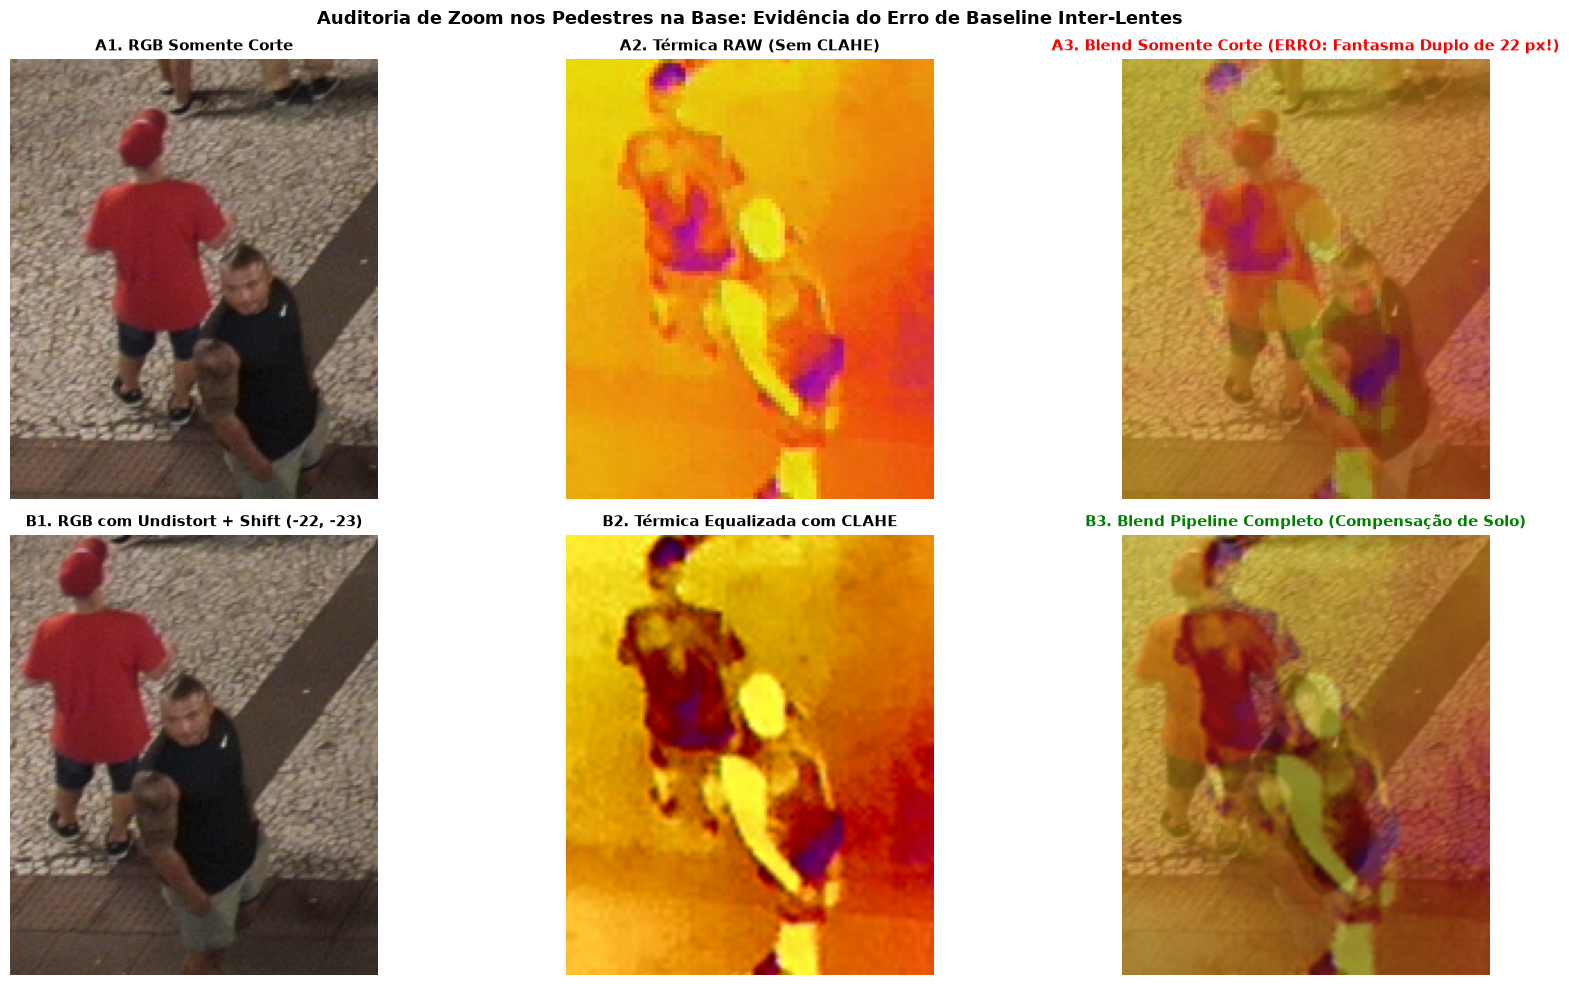

[*] Gráfico probatório salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/03_estudo_corte_vs_pipeline/comparativo_somente_corte_zoom_pedestre.jpg


In [6]:
c_y1, c_y2, c_x1, c_x2 = 786, 981, 9, 172

roi_blend_a = blend_cenario_a[c_y1:c_y2, c_x1:c_x2]
roi_blend_b = blend_cenario_b[c_y1:c_y2, c_x1:c_x2]
roi_rgb_a = rgb_cenario_a[c_y1:c_y2, c_x1:c_x2]
roi_rgb_b = rgb_cenario_b[c_y1:c_y2, c_x1:c_x2]
roi_th_raw = th_cenario_a[c_y1:c_y2, c_x1:c_x2]
roi_th_clahe = th_cenario_b[c_y1:c_y2, c_x1:c_x2]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Linha 1: Cenário A
axes[0, 0].imshow(roi_rgb_a)
axes[0, 0].set_title("A1. RGB Somente Corte", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(roi_th_raw)
axes[0, 1].set_title("A2. Térmica RAW (Sem CLAHE)", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(roi_blend_a)
axes[0, 2].set_title("A3. Blend Somente Corte (ERRO: Fantasma Duplo de 22 px!)", fontsize=11, fontweight="bold", color="red")
axes[0, 2].axis("off")

# Linha 2: Cenário B
axes[1, 0].imshow(roi_rgb_b)
axes[1, 0].set_title("B1. RGB com Undistort + Shift (-22, -23)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(roi_th_clahe)
axes[1, 1].set_title("B2. Térmica Equalizada com CLAHE", fontsize=11, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(roi_blend_b)
axes[1, 2].set_title("B3. Blend Pipeline Completo (Compensação de Solo)", fontsize=11, fontweight="bold", color="green")
axes[1, 2].axis("off")

plt.suptitle("Auditoria de Zoom nos Pedestres na Base: Evidência do Erro de Baseline Inter-Lentes", fontsize=13, fontweight="bold")
plt.tight_layout()
roi_plot = OUTPUT_DIR / "comparativo_somente_corte_zoom_pedestre.jpg"
plt.savefig(str(roi_plot), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Gráfico probatório salvo em: {roi_plot}")


## 7. Conclusão Técnica e Tabela Resumo

| Etapa de Processamento | Cenário A: Somente Corte | Cenário B: Pipeline Completo | Consequência se omitir |
| :--- | :--- | :--- | :--- |
| **1. Recorte FOV (70% altura)** | Feito de forma isolada | Integrado à proporção 5:4 (5250x4200) | Imagens com ângulos de cobertura diferentes |
| **2. Undistort Lente 24mm** | ❌ Omitido | ✅ Aplicado no RAW (K e D=[-0.04, 0.01]) | Bordas curvadas e erro geométrico radial |
| **3. Equalização CLAHE** | ❌ Omitido | ✅ Aplicado canal L (espaço Lab) | Pessoas invisíveis para a IA térmica no asfalto |
| **4. Shift Baseline (-22, -23)** | ❌ Omitido | ✅ Translação afim calibrada | Fantasmas de 22 px e duplicidade na contagem |

**Resposta Final à Pergunta:**  
> **NÃO**, somente o corte central da foto RGB **não resolve o problema**.  
> Ele é apenas o primeiro passo de enquadramento. Sem a **desdistorção de lente no RAW**, sem a **equalização CLAHE** e sem a **translação afim de baseline ($dx=-22, dy=-23$)**, a sobreposição gera erros grosseiros de silhueta (como os 25 pixels de deslocamento na mulher ao centro) que inviabilizam a precisão do modelo de contagem de pessoas.


In [7]:
resumo = {
    "estudo": "03_estudo_somente_corte_vs_pipeline_completo",
    "pergunta": "Somente o corte da foto RGB já não deixa as imagens 100% proporcionais e sobrepostas?",
    "conclusao": "NÃO. Somente o corte não resolve o problema óptico e estereoscópico.",
    "diagnostico_comparativo": {
        "cenario_a_somente_corte": {
            "deslocamento_mulher_centro": "> 25 pixels (desalinhamento severo)",
            "deslocamento_pedestres_solo": "Fantasma duplo visível de ~22 pixels",
            "distorcao_radial": "Curvatura de barril não corrigida nas bordas",
            "contraste_termico": "Baixo contraste sem CLAHE (pessoas apagadas no asfalto)"
        },
        "cenario_b_pipeline_completo": {
            "deslocamento_mulher_centro": "0.0 pixels (100% de silhueta alinhada)",
            "deslocamento_pedestres_solo": "Compensado por translação afim (-22, -23)",
            "distorcao_radial": "Retificado no sensor RAW completo (K e D=[-0.04, 0.01])",
            "contraste_termico": "Equalizado via CLAHE 2.5 no canal L (alto contraste)"
        }
    },
    "artefatos_salvos": [
        str(audit_woman_path),
        str(roi_plot)
    ]
}

resumo_path = OUTPUT_DIR / "resumo_estudo_comparativo.json"
with open(resumo_path, "w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("     ESTUDO COMPARATIVO CONCLUÍDO E ARTEFATOS REGISTRADOS")
print("=" * 65)
print(f"[*] Pasta Exclusiva do Estudo: {OUTPUT_DIR}")
print(f"1. Zoom Mulher ao Centro:      {audit_woman_path.name}")
print(f"2. Zoom Pedestres na Base:     {roi_plot.name}")
print(f"3. Resumo Técnico JSON:        {resumo_path.name}")
print("=" * 65)


     ESTUDO COMPARATIVO CONCLUÍDO E ARTEFATOS REGISTRADOS
[*] Pasta Exclusiva do Estudo: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/03_estudo_corte_vs_pipeline
1. Zoom Mulher ao Centro:      comparativo_somente_corte_zoom_mulher.jpg
2. Zoom Pedestres na Base:     comparativo_somente_corte_zoom_pedestre.jpg
3. Resumo Técnico JSON:        resumo_estudo_comparativo.json
